# Домашнее задание. Рекуррентные сети

В работе две части:

1. Дешифровка шифра Цезаря с помощью простой RNN.
2. Собственная RNN-ячейка на `nn.Linear` и генерация текста по репликам героев сериала «Симпсоны».

Стиль решения близок к лекционному notebook: посимвольная токенизация, `CHAR_TO_INDEX`, `INDEX_TO_CHAR`, `Embedding`, hidden state, `CrossEntropyLoss` и обычный цикл обучения PyTorch.

## Импорты и настройки

Импортируем библиотеки, фиксируем random seed и выбираем устройство.

In [1]:
import random
import re
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# Задание 1. Дешифровка шифра Цезаря с помощью RNN

## 1.1. Подготовка данных

Сформируем синтетические английские фразы из простого словаря. Для каждой фразы будет создана пара:

`ciphertext` — вход модели, `plaintext` — правильный ответ.

In [2]:
ALPHABET = 'abcdefghijklmnopqrstuvwxyz'
SHIFT = 3

WORDS = [
    'hello', 'world', 'deep', 'learning', 'machine', 'neural', 'network', 'recurrent',
    'sequence', 'model', 'python', 'pytorch', 'tensor', 'gradient', 'hidden', 'state',
    'data', 'train', 'validation', 'accuracy', 'loss', 'simple', 'cipher', 'caesar',
    'text', 'character', 'embedding', 'linear', 'layer', 'batch', 'epoch', 'optimizer',
    'student', 'teacher', 'homework', 'lesson', 'example', 'phrase', 'sentence', 'word',
    'learn', 'predict', 'decode', 'encode', 'secret', 'message', 'small', 'large',
    'interesting', 'fun', 'works', 'good', 'result', 'quality', 'pattern', 'input',
    'output', 'random', 'token', 'index', 'space', 'letter', 'algorithm', 'practice',
    'computer', 'science', 'modeling', 'language', 'mathematics', 'logic', 'memory',
    'future', 'past', 'current', 'next', 'previous', 'correct', 'wrong', 'answer'
]


def make_random_phrase(rng, min_words=3, max_words=8):
    phrase_len = rng.randint(min_words, max_words)
    return ' '.join(rng.choices(WORDS, k=phrase_len))


def make_plaintexts(n_samples=7000):
    rng = random.Random(SEED)
    phrases = []
    seen = set()

    while len(phrases) < n_samples:
        phrase = make_random_phrase(rng)
        if phrase not in seen:
            phrases.append(phrase)
            seen.add(phrase)

    return phrases


plaintexts = make_plaintexts()
print('Количество фраз:', len(plaintexts))
print('Примеры исходных фраз:')
for phrase in plaintexts[:5]:
    print(' ', phrase)

Количество фраз: 7000
Примеры исходных фраз:
  sequence token accuracy pytorch sequence token encode small
  deep train word
  secret output input
  train small practice hello practice input
  simple train space sequence epoch


## 1.2. Реализация шифра Цезаря

Шифр Цезаря циклически сдвигает буквы английского алфавита. Пробелы не шифруются.

In [3]:
def caesar_cipher(text, shift):
    encrypted_chars = []

    for char in text.lower():
        if char == ' ':
            encrypted_chars.append(char)
        elif char in ALPHABET:
            old_index = ALPHABET.index(char)
            new_index = (old_index + shift) % len(ALPHABET)
            encrypted_chars.append(ALPHABET[new_index])
        else:
            raise ValueError(f'Символ {char!r} не поддерживается')

    return ''.join(encrypted_chars)


def caesar_decipher(text, shift):
    # Эта функция нужна только для проверки генератора данных.
    # Нейросеть внутри модели ее не использует.
    return caesar_cipher(text, -shift)


original = 'hello world'
encrypted = caesar_cipher(original, SHIFT)

print('Оригинал:     ', original)
print('Зашифровано:  ', encrypted)
print('Расшифровано:', caesar_decipher(encrypted, SHIFT))

Оригинал:      hello world
Зашифровано:   khoor zruog
Расшифровано: hello world


## 1.3. Кодирование символов

Решение посимвольное. Порядок словаря задается явно, без `set(...)`, чтобы индексы были воспроизводимыми.

In [4]:
CAESAR_CHARS = 'abcdefghijklmnopqrstuvwxyz '
PAD_TOKEN = '<PAD>'

CAESAR_INDEX_TO_CHAR = [PAD_TOKEN] + list(CAESAR_CHARS)
CAESAR_CHAR_TO_INDEX = {char: idx for idx, char in enumerate(CAESAR_INDEX_TO_CHAR)}
CAESAR_PAD_INDEX = CAESAR_CHAR_TO_INDEX[PAD_TOKEN]
caesar_vocab_size = len(CAESAR_INDEX_TO_CHAR)


def encode_text(text, char_to_index, max_len=None):
    indices = [char_to_index[char] for char in text]

    if max_len is not None:
        indices = indices[:max_len]
        indices = indices + [CAESAR_PAD_INDEX] * (max_len - len(indices))

    return indices


def decode_indices(indices, index_to_char, skip_pad=True):
    chars = []
    for index in indices:
        index = int(index)
        char = index_to_char[index]
        if skip_pad and char == PAD_TOKEN:
            continue
        chars.append(char)
    return ''.join(chars)


example_text = 'deep learning'
example_indices = encode_text(example_text, CAESAR_CHAR_TO_INDEX)
restored_text = decode_indices(example_indices, CAESAR_INDEX_TO_CHAR)

print(example_text)
print(example_indices)
print(restored_text)
print('Размер словаря:', caesar_vocab_size)

deep learning
[4, 5, 5, 16, 27, 12, 5, 1, 18, 14, 9, 14, 7]
deep learning
Размер словаря: 28


## 1.4. Формирование train/validation выборок

Вход `X` — зашифрованные строки. Target `Y` — исходные строки. Последовательности выравниваются padding-ом, который будет игнорироваться в loss и accuracy.

In [5]:
ciphertexts = [caesar_cipher(text, SHIFT) for text in plaintexts]
max_caesar_len = max(len(text) for text in plaintexts)

X_caesar = torch.tensor(
    [encode_text(text, CAESAR_CHAR_TO_INDEX, max_caesar_len) for text in ciphertexts],
    dtype=torch.long,
)
Y_caesar = torch.tensor(
    [encode_text(text, CAESAR_CHAR_TO_INDEX, max_caesar_len) for text in plaintexts],
    dtype=torch.long,
)

caesar_dataset = TensorDataset(X_caesar, Y_caesar)
train_size = int(0.8 * len(caesar_dataset))
val_size = len(caesar_dataset) - train_size

train_caesar_dataset, val_caesar_dataset = random_split(
    caesar_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

caesar_train_loader = DataLoader(train_caesar_dataset, batch_size=128, shuffle=True)
caesar_val_loader = DataLoader(val_caesar_dataset, batch_size=128, shuffle=False)

print('X:', X_caesar.shape)
print('Y:', Y_caesar.shape)
print('Train:', len(train_caesar_dataset))
print('Validation:', len(val_caesar_dataset))

X: torch.Size([7000, 73])
Y: torch.Size([7000, 73])
Train: 5600
Validation: 1400


## 1.5. RNN-модель

Архитектура простая: индексы символов → `Embedding` → `nn.RNN` → `Linear`. Последний слой возвращает логиты для каждого символа на каждой позиции последовательности.

In [6]:
class CaesarRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_index):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x, hidden = self.rnn(x)
        return self.out(x)


caesar_model = CaesarRNN(
    vocab_size=caesar_vocab_size,
    embedding_dim=16,
    hidden_dim=64,
    pad_index=CAESAR_PAD_INDEX,
).to(device)

print(caesar_model)

sample_x, sample_y = next(iter(caesar_train_loader))
sample_logits = caesar_model(sample_x.to(device))
print('Input shape:', tuple(sample_x.shape))
print('Logits shape:', tuple(sample_logits.shape))

CaesarRNN(
  (embedding): Embedding(28, 16, padding_idx=0)
  (rnn): RNN(16, 64, batch_first=True)
  (out): Linear(in_features=64, out_features=28, bias=True)
)
Input shape: (128, 73)
Logits shape: (128, 73, 28)


## 1.6. Обучение

Loss считается по всем позициям последовательности, но padding исключается через `ignore_index=CAESAR_PAD_INDEX`.

In [7]:
def evaluate_caesar(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0
    correct_sequences = 0
    total_sequences = 0

    with torch.no_grad():
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits.reshape(-1, caesar_vocab_size), Y_batch.reshape(-1))

            mask = Y_batch != CAESAR_PAD_INDEX
            preds = logits.argmax(dim=-1)

            total_loss += loss.item() * mask.sum().item()
            correct_tokens += ((preds == Y_batch) & mask).sum().item()
            total_tokens += mask.sum().item()
            correct_sequences += (((preds == Y_batch) | (~mask)).all(dim=1)).sum().item()
            total_sequences += Y_batch.size(0)

    return {
        'loss': total_loss / total_tokens,
        'character_accuracy': correct_tokens / total_tokens,
        'sequence_accuracy': correct_sequences / total_sequences,
    }


criterion = nn.CrossEntropyLoss(ignore_index=CAESAR_PAD_INDEX)
optimizer = torch.optim.Adam(caesar_model.parameters(), lr=0.01)

CAESAR_EPOCHS = 15
caesar_train_losses = []
caesar_val_losses = []
caesar_val_accuracies = []

for epoch in range(1, CAESAR_EPOCHS + 1):
    caesar_model.train()
    train_loss_sum = 0.0
    train_tokens = 0

    for X_batch, Y_batch in caesar_train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        outputs = caesar_model(X_batch)
        loss = criterion(outputs.reshape(-1, caesar_vocab_size), Y_batch.reshape(-1))
        loss.backward()
        optimizer.step()

        tokens = (Y_batch != CAESAR_PAD_INDEX).sum().item()
        train_loss_sum += loss.item() * tokens
        train_tokens += tokens

    train_loss = train_loss_sum / train_tokens
    val_metrics = evaluate_caesar(caesar_model, caesar_val_loader, criterion)

    caesar_train_losses.append(train_loss)
    caesar_val_losses.append(val_metrics['loss'])
    caesar_val_accuracies.append(val_metrics['character_accuracy'])

    print(
        f"Epoch {epoch:02d} | train loss {train_loss:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val accuracy {val_metrics['character_accuracy']:.2%}"
    )

Epoch 01 | train loss 0.5649 | val loss 0.0051 | val accuracy 100.00%
Epoch 02 | train loss 0.0026 | val loss 0.0016 | val accuracy 100.00%
Epoch 03 | train loss 0.0013 | val loss 0.0011 | val accuracy 100.00%
Epoch 04 | train loss 0.0009 | val loss 0.0008 | val accuracy 100.00%
Epoch 05 | train loss 0.0007 | val loss 0.0006 | val accuracy 100.00%
Epoch 06 | train loss 0.0005 | val loss 0.0005 | val accuracy 100.00%
Epoch 07 | train loss 0.0004 | val loss 0.0004 | val accuracy 100.00%
Epoch 08 | train loss 0.0004 | val loss 0.0003 | val accuracy 100.00%
Epoch 09 | train loss 0.0003 | val loss 0.0003 | val accuracy 100.00%
Epoch 10 | train loss 0.0003 | val loss 0.0002 | val accuracy 100.00%
Epoch 11 | train loss 0.0002 | val loss 0.0002 | val accuracy 100.00%
Epoch 12 | train loss 0.0002 | val loss 0.0002 | val accuracy 100.00%
Epoch 13 | train loss 0.0002 | val loss 0.0002 | val accuracy 100.00%
Epoch 14 | train loss 0.0002 | val loss 0.0001 | val accuracy 100.00%
Epoch 15 | train los

Построим графики loss и accuracy для задания 1.

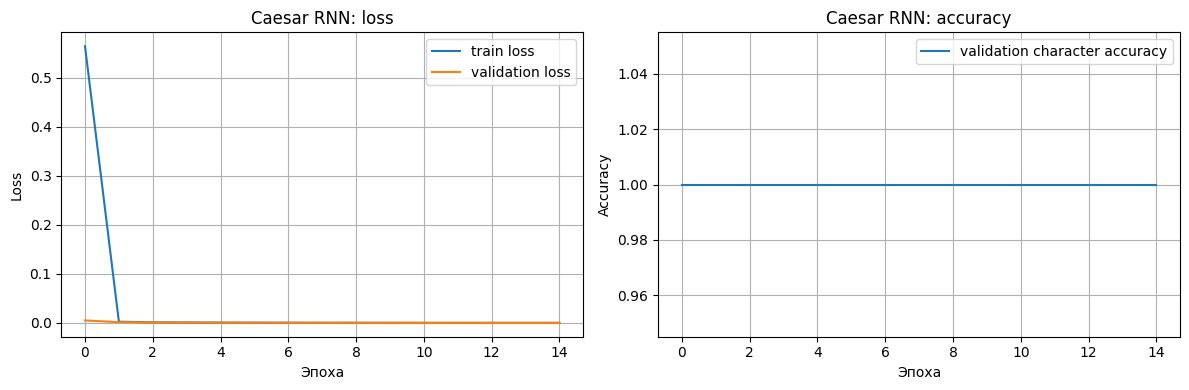

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(caesar_train_losses, label='train loss')
plt.plot(caesar_val_losses, label='validation loss')
plt.title('Caesar RNN: loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(caesar_val_accuracies, label='validation character accuracy')
plt.title('Caesar RNN: accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.7. Проверка качества

Посчитаем две метрики на отложенной выборке: accuracy по символам и accuracy всей фразы.

In [9]:
caesar_final_metrics = evaluate_caesar(caesar_model, caesar_val_loader, criterion)
caesar_character_accuracy = caesar_final_metrics['character_accuracy']
caesar_sequence_accuracy = caesar_final_metrics['sequence_accuracy']

print(f"Character accuracy: {caesar_character_accuracy:.2%}")
print(f"Sequence accuracy: {caesar_sequence_accuracy:.2%}")

Character accuracy: 100.00%
Sequence accuracy: 100.00%


## 1.8. Примеры дешифровки

Покажем примеры из validation и несколько самостоятельно написанных фраз. Модель получает только зашифрованную строку.

In [10]:
def decrypt_with_model(model, encrypted_text):
    model.eval()
    encoded = torch.tensor(
        [encode_text(encrypted_text, CAESAR_CHAR_TO_INDEX)],
        dtype=torch.long,
        device=device,
    )

    with torch.no_grad():
        logits = model(encoded)
        prediction = logits.argmax(dim=-1).squeeze(0).cpu().tolist()

    return decode_indices(prediction, CAESAR_INDEX_TO_CHAR)


print('Примеры из validation/test выборки:')
for i in range(10):
    x_item, y_item = val_caesar_dataset[i]
    encrypted_text = decode_indices(x_item.tolist(), CAESAR_INDEX_TO_CHAR)
    correct_text = decode_indices(y_item.tolist(), CAESAR_INDEX_TO_CHAR)
    predicted_text = decrypt_with_model(caesar_model, encrypted_text)

    print('\nЗашифровано:     ', encrypted_text)
    print('Правильный текст:', correct_text)
    print('Предсказание RNN:', predicted_text)
    print('Совпадение:      ', 'да' if predicted_text == correct_text else 'нет')


test_phrases = [
    'hello world',
    'deep learning',
    'recurrent neural network',
    'machine learning is fun',
    'pytorch model predicts text',
]

print('\nСамостоятельно написанные фразы:')
for phrase in test_phrases:
    # Оставляем только символы из словаря задачи.
    clean_phrase = ''.join(char for char in phrase.lower() if char in CAESAR_CHARS)
    encrypted_phrase = caesar_cipher(clean_phrase, SHIFT)
    predicted_phrase = decrypt_with_model(caesar_model, encrypted_phrase)

    print('\nЗашифровано:     ', encrypted_phrase)
    print('Правильный текст:', clean_phrase)
    print('Предсказание RNN:', predicted_phrase)
    print('Совпадение:      ', 'да' if predicted_phrase == clean_phrase else 'нет')

Примеры из validation/test выборки:

Зашифровано:      whdfkhu wrnhq fdhvdu hadpsoh uhfxuuhqw
Правильный текст: teacher token caesar example recurrent
Предсказание RNN: teacher token caesar example recurrent
Совпадение:       да

Зашифровано:      qhaw sudfwlfh skudvh vhqwhqfh whqvru flskhu skudvh
Правильный текст: next practice phrase sentence tensor cipher phrase
Предсказание RNN: next practice phrase sentence tensor cipher phrase
Совпадение:       да

Зашифровано:      fdhvdu phvvdjh zurqj ydolgdwlrq odujh lqwhuhvwlqj
Правильный текст: caesar message wrong validation large interesting
Предсказание RNN: caesar message wrong validation large interesting
Совпадение:       да

Зашифровано:      sdwwhuq sdvw fkdudfwhu ohwwhu uhvxow jrrg
Правильный текст: pattern past character letter result good
Предсказание RNN: pattern past character letter result good
Совпадение:       да

Зашифровано:      hsrfk vhtxhqfh whqvru rswlplchu phprub
Правильный текст: epoch sequence tensor optimizer memory

## 1.9. Вывод по заданию 1

Следующая ячейка формирует вывод по фактическим метрикам после обучения.

In [11]:
task1_conclusion = f'''
### Вывод по заданию 1

RNN обучалась восстанавливать исходную строку по зашифрованной строке той же длины. Итоговая character accuracy на validation/test выборке: **{caesar_character_accuracy:.2%}**. Итоговая sequence accuracy: **{caesar_sequence_accuracy:.2%}**.

Задача подходит для посимвольной RNN, потому что вход и выход являются последовательностями символов одинаковой длины. Для каждого входного символа модель должна выдать соответствующий расшифрованный символ.

Если sequence accuracy ниже 100%, оставшиеся ошибки обычно связаны с отдельными неверно восстановленными символами: для полного совпадения фразы нужно, чтобы модель правильно предсказала все позиции без исключения.
'''

display(Markdown(task1_conclusion))


### Вывод по заданию 1

RNN обучалась восстанавливать исходную строку по зашифрованной строке той же длины. Итоговая character accuracy на validation/test выборке: **100.00%**. Итоговая sequence accuracy: **100.00%**.

Задача подходит для посимвольной RNN, потому что вход и выход являются последовательностями символов одинаковой длины. Для каждого входного символа модель должна выдать соответствующий расшифрованный символ.

Если sequence accuracy ниже 100%, оставшиеся ошибки обычно связаны с отдельными неверно восстановленными символами: для полного совпадения фразы нужно, чтобы модель правильно предсказала все позиции без исключения.


# Задание 2. Собственная RNN-ячейка и генерация текста Симпсонов

## 2.1. Загрузка данных

Как в лекционном notebook, используем `data.csv` и колонку `normalized_text`. Если `data.csv` отсутствует рядом с notebook, файл будет скачан из публичного зеркала датасета The Simpsons by the Data.

In [12]:
DATA_PATH = Path('data.csv')
SIMPSONS_DATA_URL = 'https://raw.githubusercontent.com/SilvioGiancola/dlnd-Project3/master/the-simpsons-by-the-data/simpsons_script_lines.csv'


def find_or_download_simpsons_csv():
    candidates = [
        DATA_PATH,
        Path('data') / 'data.csv',
        Path('simpsons_script_lines.csv'),
        Path('data') / 'simpsons_script_lines.csv',
        Path('/kaggle/input') / 'the-simpsons-by-the-data' / 'simpsons_script_lines.csv',
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    print('data.csv не найден. Скачиваем simpsons_script_lines.csv...')
    urllib.request.urlretrieve(SIMPSONS_DATA_URL, DATA_PATH)
    return DATA_PATH


simpsons_csv_path = find_or_download_simpsons_csv()
print('Файл данных:', simpsons_csv_path)

try:
    df = pd.read_csv(simpsons_csv_path, low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv(simpsons_csv_path, engine='python', on_bad_lines='skip')

if 'normalized_text' not in df.columns:
    raise ValueError('В файле нет колонки normalized_text')

display(df.head())

data.csv не найден. Скачиваем simpsons_script_lines.csv...
Файл данных: data.csv


,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
0,9549,32,209,"Miss Hoover: No, actually, it was a little of ...",848000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,"No, actually, it was a little of both. Sometim...",no actually it was a little of both sometimes ...,31.0
1,9550,32,210,Lisa Simpson: (NEAR TEARS) Where's Mr. Bergstrom?,856000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,Where's Mr. Bergstrom?,wheres mr bergstrom,3.0
2,9551,32,211,Miss Hoover: I don't know. Although I'd sure l...,856000,True,464.0,3.0,Miss Hoover,Springfield Elementary School,I don't know. Although I'd sure like to talk t...,i dont know although id sure like to talk to h...,22.0
3,9552,32,212,Lisa Simpson: That life is worth living.,864000,True,9.0,3.0,Lisa Simpson,Springfield Elementary School,That life is worth living.,that life is worth living,5.0
4,9553,32,213,Edna Krabappel-Flanders: The polls will be ope...,864000,True,40.0,3.0,Edna Krabappel-Flanders,Springfield Elementary School,The polls will be open from now until the end ...,the polls will be open from now until the end ...,33.0


## 2.2. Подготовка текста

Удаляем `NaN`, пустые строки и символы вне маленьких английских букв и пробела. Ограничим число фраз, чтобы notebook можно было запустить за разумное время.

In [13]:
def clean_simpsons_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


phrases = (
    df['normalized_text']
    .dropna()
    .map(clean_simpsons_text)
)
phrases = [phrase for phrase in phrases if len(phrase) > 1]

MAX_PHRASES = 30000
phrases = phrases[:MAX_PHRASES]

print('Количество фраз:', len(phrases))
print('Первые 10 фраз:')
for phrase in phrases[:10]:
    print(' ', phrase)

Количество фраз: 30000
Первые 10 фраз:
  no actually it was a little of both sometimes when a disease is in all the magazines and all the news shows its only natural that you think you have it
  wheres mr bergstrom
  i dont know although id sure like to talk to him he didnt touch my lesson plan what did he teach you
  that life is worth living
  the polls will be open from now until the end of recess now just in case any of you have decided to put any thought into this well have our final statements martin
  i dont think theres anything left to say
  bart
  victory party under the slide
  mr bergstrom mr bergstrom
  hey hey he moved out this morning he must have a new job he took his copernicus costume


## 2.3. Кодирование символов

Сохраняем посимвольный подход занятия. `PAD` нужен для выравнивания последовательностей, но не участвует в loss.

In [14]:
SIMPSONS_CHARS = list('abcdefghijklmnopqrstuvwxyz ')
SIMPSONS_PAD_TOKEN = '<PAD>'
SIMPSONS_INDEX_TO_CHAR = [SIMPSONS_PAD_TOKEN] + SIMPSONS_CHARS
SIMPSONS_CHAR_TO_INDEX = {char: idx for idx, char in enumerate(SIMPSONS_INDEX_TO_CHAR)}
SIMPSONS_PAD_INDEX = SIMPSONS_CHAR_TO_INDEX[SIMPSONS_PAD_TOKEN]
simpsons_vocab_size = len(SIMPSONS_INDEX_TO_CHAR)

MAX_LEN = 50
SIMPSONS_SEQUENCE_LEN = MAX_LEN + 1


def encode_simpsons_phrase(phrase, max_len=SIMPSONS_SEQUENCE_LEN):
    indices = [SIMPSONS_CHAR_TO_INDEX[char] for char in phrase if char in SIMPSONS_CHAR_TO_INDEX]
    indices = indices[:max_len]
    indices = indices + [SIMPSONS_PAD_INDEX] * (max_len - len(indices))
    return indices


def decode_simpsons_indices(indices, skip_pad=True):
    chars = []
    for index in indices:
        index = int(index)
        char = SIMPSONS_INDEX_TO_CHAR[index]
        if skip_pad and char == SIMPSONS_PAD_TOKEN:
            continue
        chars.append(char)
    return ''.join(chars)


X_simpsons = torch.tensor(
    [encode_simpsons_phrase(phrase) for phrase in phrases],
    dtype=torch.long,
)

simpsons_dataset = TensorDataset(X_simpsons)
simpsons_train_size = int(0.9 * len(simpsons_dataset))
simpsons_val_size = len(simpsons_dataset) - simpsons_train_size
simpsons_train_dataset, simpsons_val_dataset = random_split(
    simpsons_dataset,
    [simpsons_train_size, simpsons_val_size],
    generator=torch.Generator().manual_seed(SEED),
)

simpsons_train_loader = DataLoader(simpsons_train_dataset, batch_size=128, shuffle=True)
simpsons_val_loader = DataLoader(simpsons_val_dataset, batch_size=128, shuffle=False)

print('Размер словаря:', simpsons_vocab_size)
print('Форма X:', X_simpsons.shape)
print('Train:', len(simpsons_train_dataset))
print('Validation:', len(simpsons_val_dataset))
print('Пример восстановления:', decode_simpsons_indices(X_simpsons[0].tolist()))

Размер словаря: 28
Форма X: torch.Size([30000, 51])
Train: 27000
Validation: 3000
Пример восстановления: no actually it was a little of both sometimes when 


## 2.4. Собственная RNN-ячейка

Обычная RNN на каждом шаге вычисляет новое скрытое состояние:

`h_t = tanh(W_x * x_t + W_h * h_(t-1) + b)`

Новое состояние зависит от текущего входа `x_t` и предыдущего hidden state `h_(t-1)`. Ниже рекуррентная часть реализована вручную через `nn.Linear`, `torch.tanh` и цикл по времени.

In [15]:
class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_to_hidden = nn.Linear(input_size, hidden_size)
        self.hidden_to_hidden = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x_t, h_prev):
        h_t = torch.tanh(
            self.input_to_hidden(x_t)
            + self.hidden_to_hidden(h_prev)
        )
        return h_t


class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = SimpleRNNCell(input_size, hidden_size)

    def forward(self, x, h=None):
        batch_size, sequence_length, input_size = x.shape

        if h is None:
            h = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        for t in range(sequence_length):
            h = self.cell(x[:, t, :], h)
            outputs.append(h)

        outputs = torch.stack(outputs, dim=1)
        return outputs, h

## 2.5. Модель для генерации текста

Итоговая архитектура сохраняет логику занятия: `Embedding → RNN → Linear`, но вместо готового RNN-слоя используется собственный `SimpleRNN`.

In [16]:
class SimpsonsRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, pad_index):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_index)
        self.rnn = SimpleRNN(embedding_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        outputs, hidden = self.rnn(x, hidden)
        logits = self.out(outputs)
        return logits, hidden


simpsons_model = SimpsonsRNN(
    vocab_size=simpsons_vocab_size,
    embedding_dim=30,
    hidden_dim=128,
    pad_index=SIMPSONS_PAD_INDEX,
).to(device)

print(simpsons_model)
print('Обучаемых параметров:', sum(p.numel() for p in simpsons_model.parameters() if p.requires_grad))

SimpsonsRNN(
  (embedding): Embedding(28, 30, padding_idx=0)
  (rnn): SimpleRNN(
    (cell): SimpleRNNCell(
      (input_to_hidden): Linear(in_features=30, out_features=128, bias=True)
      (hidden_to_hidden): Linear(in_features=128, out_features=128, bias=False)
    )
  )
  (out): Linear(in_features=128, out_features=28, bias=True)
)
Обучаемых параметров: 24804


## 2.6. Проверка размеров

Проверим формы тензоров до обучения.

In [17]:
check_batch = next(iter(simpsons_train_loader))[0][:4].to(device)
check_input = check_batch[:, :-1]
check_embedding = simpsons_model.embedding(check_input)
check_rnn_output, check_hidden = simpsons_model.rnn(check_embedding)
check_logits, _ = simpsons_model(check_input)

print('Input shape:', tuple(check_input.shape))
print('Embedding shape:', tuple(check_embedding.shape))
print('RNN output shape:', tuple(check_rnn_output.shape))
print('Hidden state shape:', tuple(check_hidden.shape))
print('Logits shape:', tuple(check_logits.shape))

Input shape: (4, 50)
Embedding shape: (4, 50, 30)
RNN output shape: (4, 50, 128)
Hidden state shape: (4, 128)
Logits shape: (4, 50, 28)


## 2.7. Обучение

Модель учится предсказывать следующий символ:

`вход: phrase[:, :-1]`, `target: phrase[:, 1:]`.

Перед `CrossEntropyLoss` логиты и targets разворачиваются в двумерный вид. Padding исключается через `ignore_index`.

In [18]:
def evaluate_simpsons_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch_tuple in loader:
            batch = batch_tuple[0].to(device)
            X_batch = batch[:, :-1]
            Y_batch = batch[:, 1:]

            logits, hidden = model(X_batch)
            loss = criterion(logits.reshape(-1, simpsons_vocab_size), Y_batch.reshape(-1))
            tokens = (Y_batch != SIMPSONS_PAD_INDEX).sum().item()

            total_loss += loss.item() * tokens
            total_tokens += tokens

    return total_loss / total_tokens


criterion = nn.CrossEntropyLoss(ignore_index=SIMPSONS_PAD_INDEX)
optimizer = torch.optim.Adam(simpsons_model.parameters(), lr=0.003)

SIMPSONS_EPOCHS = 10
simpsons_history = {
    'loss': {
        'train': [],
        'val': [],
    }
}

for epoch in range(1, SIMPSONS_EPOCHS + 1):
    start = time.time()
    simpsons_model.train()
    train_loss_sum = 0.0
    train_tokens = 0

    for batch_tuple in simpsons_train_loader:
        batch = batch_tuple[0].to(device)
        X_batch = batch[:, :-1]
        Y_batch = batch[:, 1:]

        optimizer.zero_grad()
        outputs, hidden = simpsons_model(X_batch)
        loss = criterion(outputs.reshape(-1, simpsons_vocab_size), Y_batch.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(simpsons_model.parameters(), max_norm=1.0)
        optimizer.step()

        tokens = (Y_batch != SIMPSONS_PAD_INDEX).sum().item()
        train_loss_sum += loss.item() * tokens
        train_tokens += tokens

    train_loss = train_loss_sum / train_tokens
    val_loss = evaluate_simpsons_loss(simpsons_model, simpsons_val_loader, criterion)
    simpsons_history['loss']['train'].append(train_loss)
    simpsons_history['loss']['val'].append(val_loss)

    print(
        f'Epoch {epoch}/{SIMPSONS_EPOCHS}. '
        f'Time: {time.time() - start:.3f}, '
        f'Train loss: {train_loss:.3f}, '
        f'Val loss: {val_loss:.3f}'
    )

Epoch 1/10. Time: 6.663, Train loss: 2.036, Val loss: 1.777
Epoch 2/10. Time: 6.398, Train loss: 1.704, Val loss: 1.647
Epoch 3/10. Time: 6.388, Train loss: 1.617, Val loss: 1.590
Epoch 4/10. Time: 6.878, Train loss: 1.573, Val loss: 1.560
Epoch 5/10. Time: 6.132, Train loss: 1.544, Val loss: 1.537
Epoch 6/10. Time: 6.677, Train loss: 1.524, Val loss: 1.526
Epoch 7/10. Time: 7.450, Train loss: 1.510, Val loss: 1.512
Epoch 8/10. Time: 6.784, Train loss: 1.497, Val loss: 1.505
Epoch 9/10. Time: 7.041, Train loss: 1.489, Val loss: 1.498
Epoch 10/10. Time: 7.868, Train loss: 1.480, Val loss: 1.490


Построим график train и validation loss.

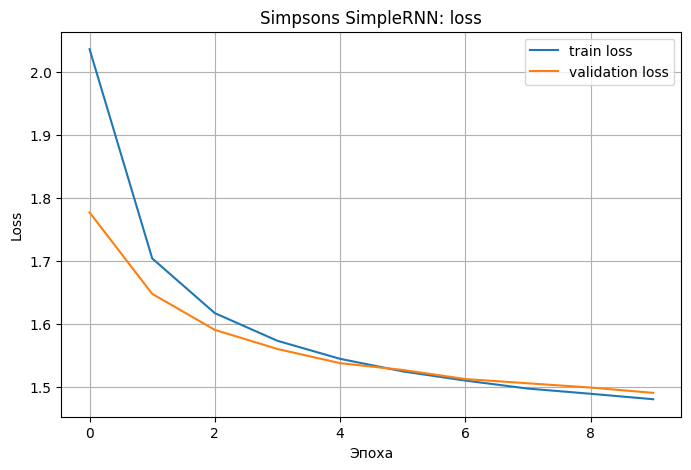

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(simpsons_history['loss']['train'], label='train loss')
plt.plot(simpsons_history['loss']['val'], label='validation loss')
plt.title('Simpsons SimpleRNN: loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 2.8. Генерация текста

Генерация авторегрессионная: модель получает начальный текст, предсказывает следующий символ, затем этот символ подается обратно как вход следующего шага. Для sampling используется temperature.

In [20]:
def prepare_start_text(text):
    text = clean_simpsons_text(text)
    text = ''.join(char for char in text if char in SIMPSONS_CHAR_TO_INDEX)
    return text if text else ' '


def generate_text(model, start_text, length=100, temperature=1.0):
    model.eval()
    generated = prepare_start_text(start_text)
    start_indices = [SIMPSONS_CHAR_TO_INDEX[char] for char in generated]
    input_tensor = torch.tensor([start_indices], dtype=torch.long, device=device)

    with torch.no_grad():
        logits, hidden = model(input_tensor)
        next_logits = logits[:, -1, :]

        for _ in range(length):
            next_logits[:, SIMPSONS_PAD_INDEX] = -1e9
            probs = torch.softmax(next_logits / temperature, dim=-1)
            next_idx = torch.multinomial(probs, 1)
            next_char = SIMPSONS_INDEX_TO_CHAR[next_idx.item()]

            generated += next_char

            logits, hidden = model(next_idx, hidden)
            next_logits = logits[:, -1, :]

    return generated


start_texts = ['homer ', 'marge ', 'bart ', 'lisa ', 'i think ']
temperatures = [0.5, 0.8, 1.0]

for temperature in temperatures:
    print(f'\nTemperature = {temperature}')
    for start_text in start_texts:
        print(generate_text(simpsons_model, start_text, length=120, temperature=temperature))


Temperature = 0.5
homer i was my basing my still was my for so lets got a stop guys he can the care this boys and so homer i dont think i want 
marge the rest stris i have this god the summer i see the track ready the last studing a from a pate to you an a simpson is a
bart you can the boy children so new where what our were god i can my tell the stop the such in the bart i wont heart em a l
lisa i dont pain to do thats the burns the first the guy on a come me now i have a to we have to the beer come to be here i 
i think you can who he have the kinda change the with smithers that was one the funny count the kids this is the share here how

Temperature = 0.8
homer i will tell that when work must right the larned i doing any was a trustic or a carebrag down try blase make hundred sm
marge out on this express and i get your son about this am i got the up marge it you for be just you not this man the restard
bart cound were gird brougy with like i do seroued to commered the whore ow and 

## 2.9. Проверка результатов

Проверим, уменьшался ли loss, и убедимся, что модель для второго задания не содержит готовые рекуррентные слои.

In [21]:
initial_train_loss = simpsons_history['loss']['train'][0]
final_train_loss = simpsons_history['loss']['train'][-1]
initial_val_loss = simpsons_history['loss']['val'][0]
final_val_loss = simpsons_history['loss']['val'][-1]

for module in simpsons_model.modules():
    assert type(module).__name__ not in {'RNN', 'RNNCell', 'GRU', 'LSTM'}

print(f'Начальный train loss: {initial_train_loss:.4f}')
print(f'Итоговый train loss: {final_train_loss:.4f}')
print(f'Начальный validation loss: {initial_val_loss:.4f}')
print(f'Итоговый validation loss: {final_val_loss:.4f}')
print('Train loss уменьшился:', final_train_loss < initial_train_loss)
print('Готовые рекуррентные слои во второй модели не используются.')

Начальный train loss: 2.0361
Итоговый train loss: 1.4799
Начальный validation loss: 1.7767
Итоговый validation loss: 1.4900
Train loss уменьшился: True
Готовые рекуррентные слои во второй модели не используются.


## Вывод по заданию 2

Следующая ячейка формирует вывод по фактическим значениям loss и примерам генерации.

In [22]:
task2_conclusion = f'''
### Вывод по заданию 2

Была реализована собственная RNN-ячейка `SimpleRNNCell`. Она вычисляет новое скрытое состояние через текущий вход и прошлое состояние: `tanh(W_x x_t + W_h h_(t-1) + b)`. Hidden state нужен, чтобы переносить информацию о предыдущих символах дальше по последовательности.

Модель обучалась предсказывать следующий символ в репликах Simpsons. Train loss изменился с **{initial_train_loss:.4f}** до **{final_train_loss:.4f}**, validation loss — с **{initial_val_loss:.4f}** до **{final_val_loss:.4f}**.

Текст генерируется авторегрессионно: каждый предсказанный символ добавляется к строке и становится входом для следующего шага. Простая RNN может уловить частые сочетания букв и пробелы, но ее возможности ограничены: ей трудно долго удерживать контекст, поэтому сгенерированный текст может быть грамматически слабым и повторяющимся.
'''

display(Markdown(task2_conclusion))


### Вывод по заданию 2

Была реализована собственная RNN-ячейка `SimpleRNNCell`. Она вычисляет новое скрытое состояние через текущий вход и прошлое состояние: `tanh(W_x x_t + W_h h_(t-1) + b)`. Hidden state нужен, чтобы переносить информацию о предыдущих символах дальше по последовательности.

Модель обучалась предсказывать следующий символ в репликах Simpsons. Train loss изменился с **2.0361** до **1.4799**, validation loss — с **1.7767** до **1.4900**.

Текст генерируется авторегрессионно: каждый предсказанный символ добавляется к строке и становится входом для следующего шага. Простая RNN может уловить частые сочетания букв и пробелы, но ее возможности ограничены: ей трудно долго удерживать контекст, поэтому сгенерированный текст может быть грамматически слабым и повторяющимся.


# Вывод

Следующая ячейка формирует итоговое сравнение двух задач по фактическим результатам запуска.

In [23]:
final_conclusion = f'''
# Итоговые выводы

**Шифр Цезаря** — это задача sequence-to-sequence одинаковой длины: зашифрованная последовательность символов преобразуется в исходную последовательность. Модель выдает класс символа для каждой позиции. В этом запуске character accuracy составила **{caesar_character_accuracy:.2%}**, sequence accuracy — **{caesar_sequence_accuracy:.2%}**.

**Simpsons** — это задача предсказания следующего символа: предыдущие символы используются для предсказания следующего. При генерации предсказанный символ подается обратно в модель и становится входом следующего шага.

В обеих задачах RNN использует скрытое состояние, но постановка различается. В первом задании ответ нужен для каждой позиции уже известной входной строки. Во втором задании модель строит продолжение текста, поэтому ошибки могут накапливаться при генерации.
'''

display(Markdown(final_conclusion))


# Итоговые выводы

**Шифр Цезаря** — это задача sequence-to-sequence одинаковой длины: зашифрованная последовательность символов преобразуется в исходную последовательность. Модель выдает класс символа для каждой позиции. В этом запуске character accuracy составила **100.00%**, sequence accuracy — **100.00%**.

**Simpsons** — это задача предсказания следующего символа: предыдущие символы используются для предсказания следующего. При генерации предсказанный символ подается обратно в модель и становится входом следующего шага.

В обеих задачах RNN использует скрытое состояние, но постановка различается. В первом задании ответ нужен для каждой позиции уже известной входной строки. Во втором задании модель строит продолжение текста, поэтому ошибки могут накапливаться при генерации.
